# HDI Predictor - Data Analysis & Model Training

This notebook loads the raw UNDP wide-format CSV, wrangles it into long-format
(one row per country-year), then runs EDA and trains a Linear Regression model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Load & Wrangle Dataset

The raw CSV is in **wide format** (195 countries × 880 columns). HDI and each
feature are stored as year-suffixed columns e.g. `Human Development Index (2021)`.
We melt it into a **long format** (one row per country-year) with clean column names.

In [2]:
# ---- Constants ---------------------------------------------------------------
YEARS = list(range(1990, 2022))   # 1990-2021

FEATURE_MAP = {
    'Life_Expectancy':          'Life Expectancy at Birth',
    'Expected_Years_Schooling': 'Expected Years of Schooling',
    'Mean_Years_Schooling':     'Mean Years of Schooling',
    'GNI_per_capita':           'Gross National Income Per Capita',
    'Gender_Dev_Index':         'Gender Development Index',
    'Gender_Ineq_Index':        'Gender Inequality Index',
    'CO2_per_capita':           'Carbon dioxide emissions per capita (production) (tonnes)',
}
TARGET        = 'HDI'
TARGET_PREFIX = 'Human Development Index'
FEATURE_COLS  = list(FEATURE_MAP.keys())

# ---- Helper ------------------------------------------------------------------
def find_col(df, prefix, year):
    """Return the column name matching prefix + (year), or None."""
    target = f'({year})'
    for col in df.columns:
        if col.startswith(prefix) and col.strip().endswith(target):
            return col
    return None

# ---- Load raw CSV ------------------------------------------------------------
raw = pd.read_csv('../data/hdi_dataset.csv')
print(f'Raw shape: {raw.shape}  →  {raw.shape[0]} countries, {raw.shape[1]} columns')
raw.head(2)

Raw shape: (195, 880)  →  195 countries, 880 columns


,ISO3,Country,Human Development Groups,UNDP Developing Regions,HDI Rank (2021),Human Development Index (1990),Human Development Index (1991),Human Development Index (1992),Human Development Index (1993),Human Development Index (1994),...,Material footprint per capita (tonnes) (2012),Material footprint per capita (tonnes) (2013),Material footprint per capita (tonnes) (2014),Material footprint per capita (tonnes) (2015),Material footprint per capita (tonnes) (2016),Material footprint per capita (tonnes) (2017),Material footprint per capita (tonnes) (2018),Material footprint per capita (tonnes) (2019),Material footprint per capita (tonnes) (2020),Material footprint per capita (tonnes) (2021)
0,AFG,Afghanistan,Low,SA,180.0,0.273,0.279,0.287,0.297,0.292,...,1.86,1.88,1.66,1.62,1.66,1.41,1.32,1.38,1.38,1.38
1,AGO,Angola,Medium,SSA,148.0,NaN,NaN,NaN,NaN,NaN,...,4.09,4.53,3.97,3.59,2.79,2.64,2.28,2.18,2.18,2.18


In [3]:
# ---- Melt wide → long --------------------------------------------------------
rows = []
for year in YEARS:
    hdi_col = find_col(raw, TARGET_PREFIX, year)
    if hdi_col is None:
        continue
    feat_cols = {feat: find_col(raw, prefix, year) for feat, prefix in FEATURE_MAP.items()}

    for _, cr in raw.iterrows():
        record = {
            'Country': cr['Country'],
            'ISO3':    cr['ISO3'],
            'Year':    year,
            TARGET:    pd.to_numeric(cr[hdi_col], errors='coerce'),
        }
        for feat, col in feat_cols.items():
            record[feat] = pd.to_numeric(cr[col], errors='coerce') if col else np.nan
        rows.append(record)

df_long = pd.DataFrame(rows)
print(f'Long-format shape (before cleaning): {df_long.shape}')
df_long.head()

Long-format shape (before cleaning): (6240, 11)


,Country,ISO3,Year,HDI,Life_Expectancy,Expected_Years_Schooling,Mean_Years_Schooling,GNI_per_capita,Gender_Dev_Index,Gender_Ineq_Index,CO2_per_capita
0,Afghanistan,AFG,1990,0.273,45.9672,2.50405,0.971125,2684.550019,0.595,NaN,0.209727
1,Angola,AGO,1990,NaN,41.8933,3.53748,NaN,4845.706901,NaN,0.725,0.429586
2,Albania,ALB,1990,0.647,73.1439,11.60293,7.354632,4742.215529,0.922,NaN,1.656902
3,Andorra,AND,1990,NaN,78.4063,10.79878,NaN,43773.146500,NaN,NaN,7.461153
4,United Arab Emirates,ARE,1990,0.728,71.9004,10.47456,5.759906,102433.136000,0.961,0.659,28.277672


## 2. Handle Missing Values

In [4]:
# Drop rows missing the target or any feature
cols_needed = FEATURE_COLS + [TARGET]
before = len(df_long)
df = df_long.dropna(subset=cols_needed).reset_index(drop=True)
print(f'Dropped {before - len(df)} rows with NaN → {len(df)} clean rows remain.')
df.describe()

Dropped 1686 rows with NaN → 4554 clean rows remain.


,Year,HDI,Life_Expectancy,Expected_Years_Schooling,Mean_Years_Schooling,GNI_per_capita,Gender_Dev_Index,Gender_Ineq_Index,CO2_per_capita
count,4554.000000,4554.000000,4554.000000,4554.000000,4554.000000,4554.000000,4554.000000,4554.000000,4554.000000
mean,2007.210584,0.676463,69.317731,12.350778,7.862068,17257.597859,0.924215,0.407862,4.759777
std,8.809089,0.167304,9.375604,3.369341,3.335504,18349.247658,0.079851,0.201634,5.992659
min,1990.000000,0.216000,39.969200,2.059570,0.559420,416.032660,0.485000,0.013000,0.020070
25%,2000.000000,0.545250,63.183625,10.236450,5.176977,3830.907128,0.883000,0.231000,0.676002
50%,2008.000000,0.703000,71.392450,12.602420,8.128814,10500.909435,0.950000,0.431000,2.516020
75%,2015.000000,0.809000,76.575925,14.781915,10.662860,24831.850582,0.980000,0.576000,6.973446
max,2021.000000,0.962000,84.783900,23.088921,14.132150,104640.280700,1.072000,0.822000,61.793410


## 3. Exploratory Data Analysis

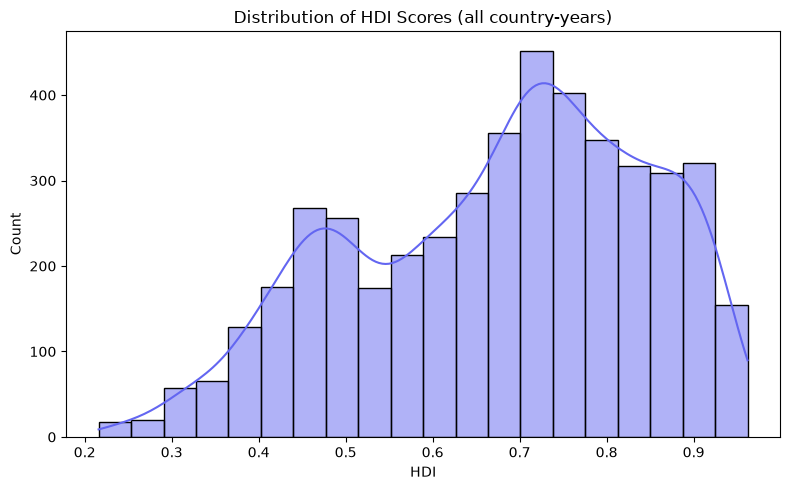

In [5]:
# HDI distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['HDI'], kde=True, bins=20, color='#6366f1')
plt.title('Distribution of HDI Scores (all country-years)')
plt.xlabel('HDI')
plt.tight_layout()
plt.show()

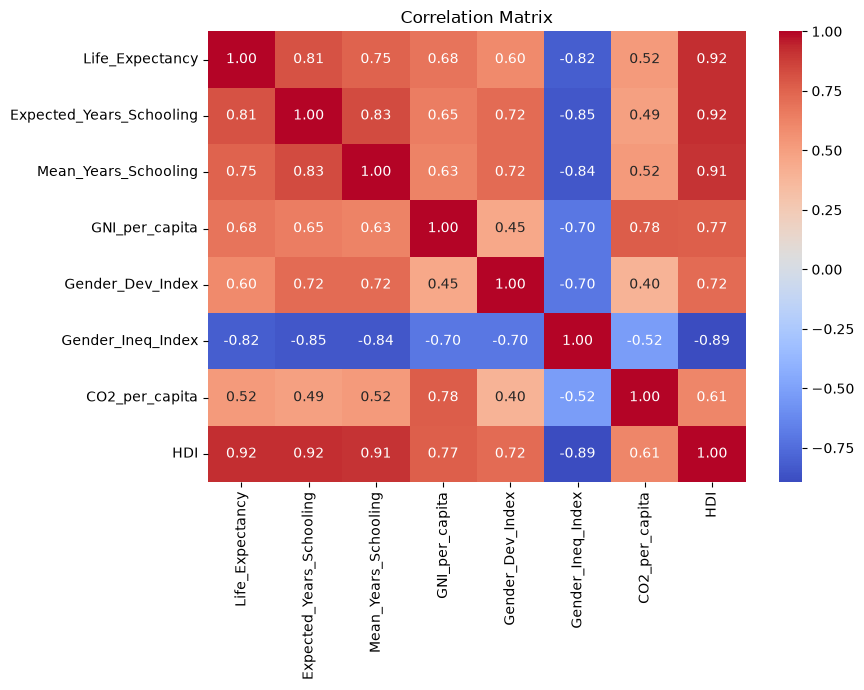

In [6]:
# Correlation heatmap (features + target only)
plt.figure(figsize=(9, 7))
corr = df[FEATURE_COLS + [TARGET]].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

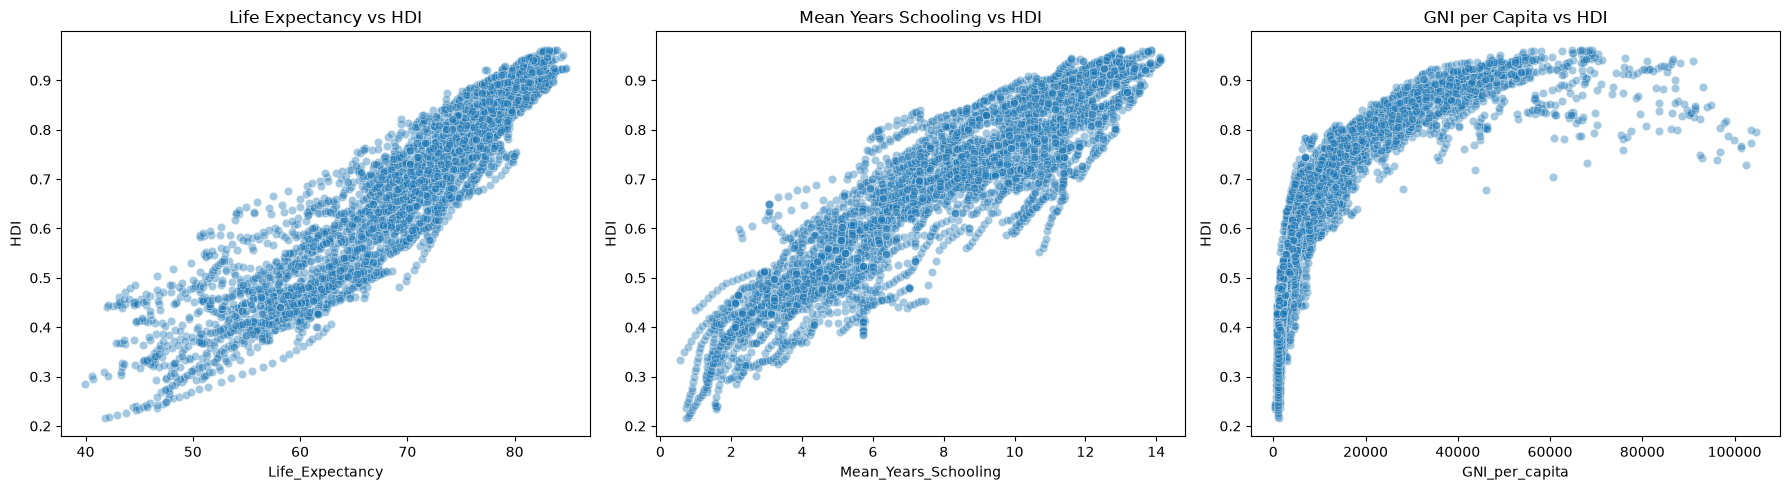

In [7]:
# Scatter: top 3 features vs HDI
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(x='Life_Expectancy',      y='HDI', data=df, alpha=0.4, ax=axes[0])
sns.scatterplot(x='Mean_Years_Schooling', y='HDI', data=df, alpha=0.4, ax=axes[1])
sns.scatterplot(x='GNI_per_capita',       y='HDI', data=df, alpha=0.4, ax=axes[2])
axes[0].set_title('Life Expectancy vs HDI')
axes[1].set_title('Mean Years Schooling vs HDI')
axes[2].set_title('GNI per Capita vs HDI')
plt.tight_layout()
plt.show()

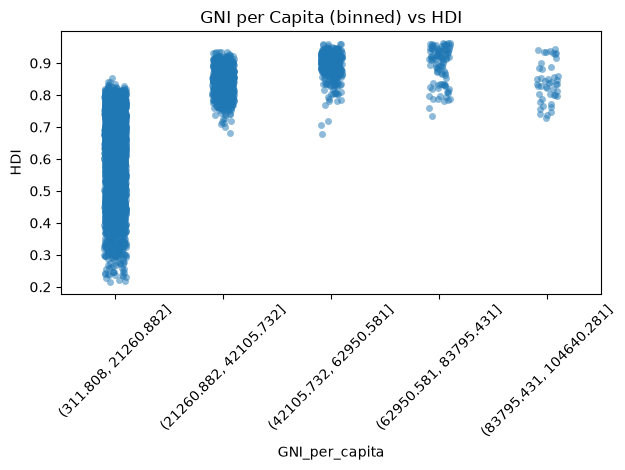

In [8]:
# GNI binned vs HDI
sns.stripplot(x=pd.cut(df['GNI_per_capita'], bins=5), y=df['HDI'], alpha=0.5)
plt.xticks(rotation=45)
plt.title('GNI per Capita (binned) vs HDI')
plt.tight_layout()
plt.show()

## 4. Feature Selection & Train/Test Split

In [9]:
X = df[FEATURE_COLS]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Train: (3643, 7)  |  Test: (911, 7)


## 5. Feature Scaling

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('Scaling complete.')

Scaling complete.


## 6. Train Linear Regression Model

In [11]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)
print('Model trained.')

Model trained.


## 7. Evaluate Model

In [12]:
y_pred = model.predict(X_test_scaled)

mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f'MSE:      {mse:.6f}')
print(f'RMSE:     {rmse:.6f}')
print(f'R² Score: {r2:.4f}')

MSE:      0.000395
RMSE:     0.019883
R² Score: 0.9865


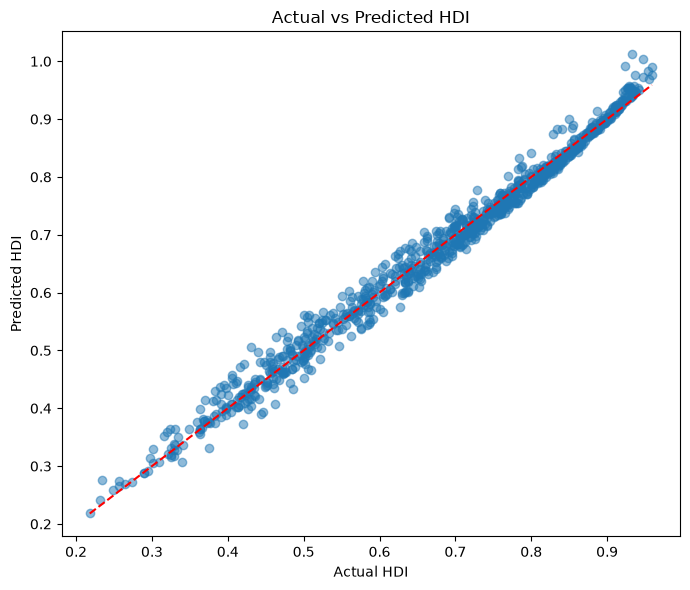

In [13]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual HDI')
plt.ylabel('Predicted HDI')
plt.title('Actual vs Predicted HDI')
plt.tight_layout()
plt.show()

## 8. Save Model & Scaler with Pickle

In [14]:
os.makedirs('../model', exist_ok=True)

with open('../model/hdi_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('../model/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('Model and scaler saved to ../model/')

Model and scaler saved to ../model/


## 9. Classification Helper & Scenario Testing

In [15]:
def classify_hdi(score):
    if score >= 0.800:
        return 'Very High Human Development'
    elif score >= 0.700:
        return 'High Human Development'
    elif score >= 0.550:
        return 'Medium Human Development'
    else:
        return 'Low Human Development'

test_cases = [
    {'Life_Expectancy': 82,  'Mean_Years_Schooling': 13.5, 'Expected_Years_Schooling': 17,  'GNI_per_capita': 55000, 'Gender_Dev_Index': 0.99, 'Gender_Ineq_Index': 0.05, 'CO2_per_capita': 7.0},
    {'Life_Expectancy': 68,  'Mean_Years_Schooling': 7.5,  'Expected_Years_Schooling': 11,  'GNI_per_capita': 8000,  'Gender_Dev_Index': 0.90, 'Gender_Ineq_Index': 0.35, 'CO2_per_capita': 3.0},
    {'Life_Expectancy': 58,  'Mean_Years_Schooling': 4.0,  'Expected_Years_Schooling': 7,   'GNI_per_capita': 1800,  'Gender_Dev_Index': 0.80, 'Gender_Ineq_Index': 0.60, 'CO2_per_capita': 0.5},
]

print(f'{'Scenario':<10} | {'Predicted HDI':<15} | Category')
print('-' * 60)
for i, case in enumerate(test_cases, 1):
    row = pd.DataFrame([case])[FEATURE_COLS]
    row_scaled = scaler.transform(row)
    pred = model.predict(row_scaled)[0]
    print(f'Case {i:<5} | {pred:<15.3f} | {classify_hdi(pred)}')

Scenario   | Predicted HDI   | Category
------------------------------------------------------------
Case 1     | 0.953           | Very High Human Development
Case 2     | 0.630           | Medium Human Development
Case 3     | 0.445           | Low Human Development
